In [11]:
import parcels
import geopandas as gpd 
import sys
import sys
from pathlib import Path
import xarray as xr
from datetime import timedelta
# go to project root (parent of Parcles/)
sys.path.insert(0, str(Path.cwd().parent))
from functions.funcs import *
import functions.plotting

In [3]:
##load some data 
## Loads the Velosity field
fname = r"..\Data\krigging_field.nc"
field = xr.open_dataset(fname )
##Loads the dFADs 
ds = gpd.read_parquet(r"..\Data\Mapped_SAT_MI_Cleanedspeeds.parquet")

In [4]:
target_date = pd.to_datetime("2023-7-12", format="%Y-%m-%d") ## picks dFAD locations one day after this date 

ds_active = querry_date(ds, date = target_date) ## All of the active dFADs at this time 
ds_active = ds_active.reset_index()
columns = ["TimeStamp", "x_speed", "y_speed"]
ds_locations = pd.DataFrame()
for label in columns: 
    longlist, ids = Column_to_List(ds_active, label, idlist = True)
     
    ds_locations[label] = longlist
lat, lon  = list_of_latlon(ds_active, droplast= False)
ds_locations["lat"] = lat
ds_locations["lon"] =lon
ds_locations["BuoyName"] = ids
ds_locations.TimeStamp = pd.to_datetime(ds_locations.TimeStamp)

##Filter Timestep by certain threshhold to get locations of FADS within closes  
## UPDATE:This might be better to interp these onto the specific time. 
hourlim = 24
time_threshhold  = pd.Timedelta(hours= hourlim)
time_upper  = target_date + time_threshhold ## This is set for dFADs one day after the date 
time_lower = target_date 
ds_locations = ds_locations.query(f"TimeStamp > @time_lower")
ds_locations = ds_locations.query(f"TimeStamp < @time_upper")
print(f"Amount of sampled dFAD within {hourlim} hrs : {len(ds_locations)}")
ds_locations = ds_locations.drop_duplicates(subset=["lat"], keep="first")
ds_locations = ds_locations.drop_duplicates(subset=["lon"], keep="first").reset_index(drop = True)

## New get only the first point of the day for the forcast.

dFADs = ds_locations.sort_values('TimeStamp').groupby("BuoyName").first()
print(f"Number of Unique dFADs/ points avalable: {len(dFADs)}")
dFADs = dFADs.reset_index()

Amount of sampled dFAD within 24 hrs : 236
Number of Unique dFADs/ points avalable: 43


In [5]:
## Make the model... 
filenames = {"uo": fname, "vo": fname}
variables  = {"U": "uo", "V": "vo"}
dimensions = {"lat": "lat", "lon": "lon"}
field_t = field.sel(time = target_date, method = "nearest").drop_vars("time") ## Not 
runtime = pd.Timedelta(days =7)

# fieldsetperm = parcels.FieldSet.from_netcdf(filenames, variables, dimensions)
fieldset  = parcels.FieldSet.from_xarray_dataset(field_t, variables, dimensions, allow_time_extrapolation= True) 
fieldset.add_constant("halo_west", fieldset.U.grid.lon[0])
fieldset.add_constant("halo_east", fieldset.U.grid.lon[-1])
fieldset.add_constant("halo_north", fieldset.U.grid.lat[-1])
fieldset.add_constant("halo_south", fieldset.U.grid.lat[0])
fieldset.add_periodic_halo(zonal = True , meridional= True)

def boundryCondition(particle, fieldset,time):
    if particle.lon < fieldset.halo_west or particle.lon > fieldset.halo_east:
        particle.delete()
    if particle.lat < fieldset.halo_south or particle.lat > fieldset.halo_north:
        particle.delete()
        
def Age(particle, fieldset, time):
    particle.age += particle.dt / 3600
    
dFADs["timedelta"] = (dFADs.TimeStamp - target_date).dt.total_seconds()

Particles = parcels.ScipyParticle.add_variable("age", initial = 0) 
Particles = Particles.add_variable("Buoyindex", to_write = 'once')

pset = parcels.ParticleSet.from_list(fieldset, pclass = Particles , lon = dFADs.lon.to_list(), 
                                     lat = dFADs.lat.to_list() , time = dFADs.timedelta, Buoyindex = dFADs.index.values) 

output_file = pset.ParticleFile(name = "TestParticleFile.zarr", outputdt =timedelta(hours= 1))


In [6]:
pset.execute([parcels.AdvectionRK4, boundryCondition, Age], 
             runtime = timedelta(days = 7), ##this should be 8 days 
             dt = timedelta(minutes =5), 
             output_file = output_file, 
              )

INFO: Output files are stored in TestParticleFile.zarr.


c:\FATE\.venv\Lib\site-packages\parcels\particleset.py:1127: ParticleSetWarning: Some of the particles have a start time difference that is not a multiple of outputdt. This could cause the first output of some of the particles that start later in the simulation to be at a different time than expected.
  _warn_outputdt_release_desync(outputdt, starttime, self.particledata.data["time_nextloop"])


100%|██████████| 604800.0/604800.0 [00:30<00:00, 19839.11it/s]


In [7]:
buoy_list = dFADs.BuoyName.tolist()
ds_filtered = ds_active[ds_active["BuoyName"].isin(buoy_list)].reset_index(drop = True)

In [8]:
print(ds_filtered.columns)

Index(['level_0', 'index', 'BuoyName', 'MinOfDate', 'MaxOfDate', 'TimeStamp',
       'geometry', 'x_deg', 'y_deg', 'x_km', 'y_km', 'xy_km',
       'Delta_Timestamps', 'x_speed', 'y_speed', 'xy_speed', 'points_removed',
       'Masked_array', 'points_removed2', 'Masked_array2',
       'Masked_array_combined', 'mapped_v', 'mapped_u'],
      dtype='object')


In [9]:
def Forcast_snippit(ds: gpd.GeoDataFrame, dates, startdate, length)-> gpd.GeoDataFrame: 
    """Grad only the snipbit of dFAD trajectory that lines up with forcast window"""
    ds_s = ds.copy()
    forecast_end = startdate + length
    for i in range(len(ds)): ## Try and grab at the exact start times from dates they should be the same
        timelist = (ds_s.at[i,"TimeStamp"])
        timelist = pd.to_datetime(timelist)
        mask = (timelist >= dates[i]) & (timelist <= forecast_end)
        timelist = timelist[mask]
        coords = np.asarray(ds.at[i,"geometry"].coords)
        filtered_coords = coords[mask]
        ds_s.at[i,"TimeStamp"] = timelist
        if len(filtered_coords) > 1:
             ds_s.at[i,"geometry"] = sp.geometry.LineString(filtered_coords)
        else: 
            ds_s.at[i,"geometry"] = None
    return ds_s

ds_short_t = Forcast_snippit(ds_filtered, dFADs.TimeStamp, target_date, pd.Timedelta(days = 7))

Text(0, 0.5, 'Meridional distance [m]')

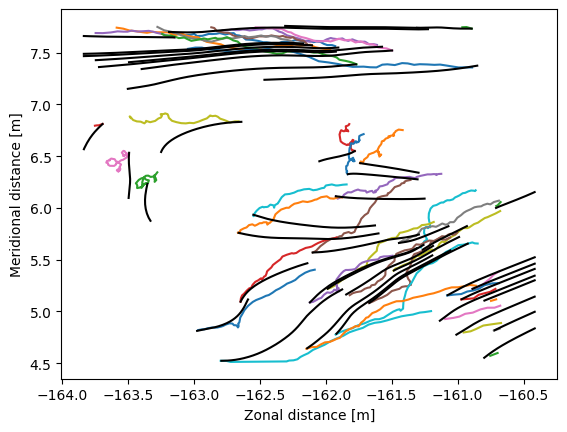

In [14]:
ds = xr.open_zarr("TestParticleFile.zarr", decode_timedelta=True)
fig, ax = plt.subplots()
for i in range(len(ds_filtered)):
    ax = functions.plotting.OneTrajectory(ds_short_t, i, ax)

ax.plot(ds.lon.T, ds.lat.T, "-", color = "k")
#plt.scatter(dFADs.lon, dFADs.lat)
ax.set_xlabel("Zonal distance [m]")
ax.set_ylabel("Meridional distance [m]")

#### Going from model output to CSV Needed
- ideally this is going to be stored in memory and only write when the CSV is full

In [15]:
output = xr.open_zarr("TestParticleFile.zarr")
display(output)

C:\Users\czerfass\AppData\Local\Temp\1\ipykernel_24916\3507518125.py:1: FutureWarning: In a future version, xarray will not decode the variable 'time' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  output = xr.open_zarr("TestParticleFile.zarr")


<xarray.Dataset> Size: 175kB
Dimensions:     (trajectory: 43, obs: 168)
Coordinates:
  * obs         (obs) int32 672B 0 1 2 3 4 5 6 7 ... 161 162 163 164 165 166 167
  * trajectory  (trajectory) int64 344B 18 39 3 6 10 13 15 ... 11 12 22 25 35 38
Data variables:
    Buoyindex   (trajectory) float32 172B dask.array<chunksize=(43,), meta=np.ndarray>
    age         (trajectory, obs) float32 29kB dask.array<chunksize=(43, 1), meta=np.ndarray>
    lat         (trajectory, obs) float32 29kB dask.array<chunksize=(43, 1), meta=np.ndarray>
    lon         (trajectory, obs) float32 29kB dask.array<chunksize=(43, 1), meta=np.ndarray>
    time        (trajectory, obs) timedelta64[ns] 58kB dask.array<chunksize=(43, 1), meta=np.ndarray>
    z           (trajectory, obs) float32 29kB dask.array<chunksize=(43, 1), meta=np.ndarray>
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        NewParticleAdvectionRK4boundryConditionAge
    parcels_mesh:           spherical
    parcels_version:        3.1.4

In [54]:
# print(output.time[2,:].values/1e9)
# print(output.age[2,:].values*3600)

tage = output.age[10,:].values

tage

array([8.33333358e-02, 1.08333325e+00, 2.08333349e+00, 3.08333254e+00,
       4.08333158e+00, 5.08333349e+00, 6.08333540e+00, 7.08333731e+00,
       8.08333874e+00, 9.08333492e+00, 1.00833311e+01, 1.10833273e+01,
       1.20833235e+01, 1.30833197e+01, 1.40833158e+01, 1.50833120e+01,
       1.60833092e+01, 1.70833168e+01, 1.80833244e+01, 1.90833321e+01,
       2.00833397e+01, 2.10833473e+01, 2.20833549e+01, 2.30833626e+01,
       2.40833702e+01, 2.50833778e+01, 2.60833855e+01, 2.70833931e+01,
       2.80834007e+01, 2.90834084e+01, 3.00834160e+01, 3.10834236e+01,
       3.20834274e+01, 3.30834122e+01, 3.40833969e+01, 3.50833817e+01,
       3.60833664e+01, 3.70833511e+01, 3.80833359e+01, 3.90833206e+01,
       4.00833054e+01, 4.10832901e+01, 4.20832748e+01, 4.30832596e+01,
       4.40832443e+01, 4.50832291e+01, 4.60832138e+01, 4.70831985e+01,
       4.80831833e+01, 4.90831680e+01, 5.00831528e+01, 5.10831375e+01,
       5.20831223e+01, 5.30831070e+01, 5.40830917e+01, 5.50830765e+01,
      

In [16]:
output["date"] = (["trajectory", "obs"],output.time.values + target_date)
output["leadtime"] = (["trajectory", "obs"],(output.time[:,:] - output.time[:,0]).values)
output["leadtimeint"] = (["trajectory", "obs"],output.leadtime[:,:].values.astype("int64")/10e9)

In [17]:
limelist = ds_short_t.iloc[i,:].TimeStamp -  ds_short_t.iloc[i,:].TimeStamp[0]
limelist.astype("int64")/1e9 ### lead time in seconds


Index([0.0, 14460.0], dtype='float64')

In [18]:
print(len(dFADs))
print(len(ds_short_t))

43
43


In [19]:
dsout = pd.DataFrame(columns = ["BuoyID","Time", "lat_true", "lon_true", "lat_forcast", "lon_forcast", "leadtime"])
masklarge =~ np.isnan(output.lat[:,:].values)
dFADs_s = dFADs.iloc[output.Buoyindex.values]
# ds_short_ts = ds_short_t[ds_short_t["BuoyName"].isin(dFADs_s.BuoyName.values)]
order = dFADs_s.BuoyName.tolist()
order_map = {name: i for i, name in enumerate(order)}
mask = ds_short_t["BuoyName"].isin(order)
ds_short_ts = (
    ds_short_t[mask]
    .assign(order_index=lambda df: df["BuoyName"].map(order_map))
    .sort_values("order_index")
    .drop(columns="order_index")
    .reset_index(drop=True)
)

for i, index in enumerate(output.Buoyindex.values): 
    id = dFADs.BuoyName[index]
    #row = ds_short_t.query("BuoyName == @id") ## could be faster to sort ds_short first then use index to find dFAD
    row=  ds_short_ts.iloc[i]
    Times= row["TimeStamp"]
    starttime = Times[0]
    dFAD_leadtime = (Times - starttime).astype("int64")/1e9 ## convets leadtime to seconds
    mask = masklarge[i,:] 
    leadtimes = output.age[i,:].values[mask]*3600 ## converts to seconds also. 
    lats = output.lat[i,:].values[mask]
    lons = output.lon[i,:].values[mask]
    lat_interp = np.interp(dFAD_leadtime[1:], leadtimes,lats)
    lon_interp = np.interp(dFAD_leadtime[1:], leadtimes, lons) 
    lon_true, lat_true= row["geometry"].xy
    Bouylist = [id]*len(lat_true[1:]) 
    #print(len(Bouylist), len (Times), len(lat_true), len(lon_true), len(lon_interp), len(lat_interp), len(leadtimes))
    dstemp= pd.DataFrame({"BuoyID": Bouylist, "Time": Times[1:], "lat_true": lat_true[1:],"lon_true":lon_true[1:], "lat_forcast": lat_interp, "lon_forcast": lon_interp, "leadtime": dFAD_leadtime[1:]/3600 })
    dsout = pd.concat([dsout,dstemp])


C:\Users\czerfass\AppData\Local\Temp\1\ipykernel_24916\3564802605.py:33: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  dsout = pd.concat([dsout,dstemp])


In [ ]:
dsout.head(40)

,BuoyID,Time,lat_true,lon_true,lat_forcast,lon_forcast,leadtime
0,SLX+404579,2023-07-12 08:02:00,5.68712,-161.41293,5.664705,-161.425894,4.016667
1,SLX+404579,2023-07-12 12:02:00,5.68542,-161.38988,5.668279,-161.407678,8.016667
2,SLX+404579,2023-07-12 16:02:00,5.70233,-161.37303,5.671906,-161.391335,12.016667
3,SLX+404579,2023-07-12 20:02:00,5.72278,-161.34242,5.675591,-161.376703,16.016667
4,SLX+404579,2023-07-13 00:01:00,5.72853,-161.31505,5.679303,-161.363635,20.000000
5,SLX+404579,2023-07-13 04:01:00,5.75883,-161.29472,5.683058,-161.351766,24.000000
6,SLX+404579,2023-07-13 08:02:00,5.79812,-161.27220,5.686850,-161.341028,28.016667
7,SLX+404579,2023-07-13 12:02:00,5.80632,-161.24660,5.690627,-161.331272,32.016667
8,SLX+404579,2023-07-13 16:05:00,5.81467,-161.22180,5.694435,-161.321802,36.066667
9,SLX+404579,2023-07-13 20:01:00,5.82318,-161.18908,5.698110,-161.313159,40.000000
